In [1]:
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import hbonds
import matplotlib.pyplot as plt
import nglview as nv
import sys
sys.path.append('/home/chemistry/MD')
import MDcode as MDC
import importlib

/usr/lib/python3.10/site-packages/MDAnalysis/analysis/hbonds/hbond_autocorrel.py:52: DeprecationWarning: This module was moved to MDAnalysis.analysis.hydrogenbonds.hbond_autocorrel; hbonds.hbond_autocorrel will be removed in 3.0.0.
  warnings.warn(wmsg, category=DeprecationWarning)


In [2]:
%matplotlib notebook

In [3]:
# Loads just a .gro single-frame file and checks if there are positions and velocities
# grofile = "System0_separated.gro"
# grofile = "System0.gro"
grofile = "confout.gro"
uframe = mda.Universe(grofile)
print(uframe.trajectory.ts.has_positions)
print(uframe.trajectory.ts.has_velocities)

True
True


In [4]:
# Loads the data
uframe = mda.Universe(grofile)
print(np.shape(uframe.atoms.positions))
print(uframe.trajectory.ts.has_positions)
print(uframe.trajectory.ts.has_velocities)

(11655, 3)
True
True


In [5]:
# Turn this on if we want to look at a single frame
TOTview = nv.show_mdanalysis(uframe)
TOTview.clear()
# TOTview.add_contact(hydrogen_bond=True) # This slows things down a lot
TOTview.add_representation('licorice',selection='SOL',opacity=0.3)
TOTview.add_representation('ball+stick',selection='DNA')
TOTview.add_representation('ball+stick',selection='NA',color='green',radius=.3)
TOTview.camera='orthographic'

TOTview.center()
TOTview.add_unitcell()
TOTview.control.rotate([0,1,0,0])
TOTview

NGLWidget()

In [6]:
# Turn this on if we want to look at the trajectory
xtcfile = "traj.xtc"
u = mda.Universe(grofile,xtcfile)
TOTview = nv.show_mdanalysis(u)
TOTview.clear()
TOTview.add_contact(hydrogen_bond=True) # This slows things down a lot
TOTview.add_representation('licorice',selection='SOL',opacity=0.3)
# TOTview.add_representation('surface',selection='SOL',opacity=0.7)
TOTview.add_representation('ball+stick',selection='DNA')
TOTview.add_representation('ball+stick',selection='NA',color='green',radius=.3)
TOTview.add_representation('licorice',selection='2824SOL')
TOTview.add_representation('licorice',selection='2562SOL')
TOTview.add_representation('ball+stick',selection='1507SOL')
TOTview.add_representation('ball+stick',selection='1508SOL')
TOTview.add_representation('ball+stick',selection='1509SOL')
TOTview.add_representation('ball+stick',selection='1510SOL')
TOTview.add_representation('ball+stick',selection='1511SOL')
TOTview.add_representation('ball+stick',selection='1512SOL')
TOTview.add_representation('ball+stick',selection='1513SOL')
TOTview.add_representation('ball+stick',selection='1514SOL')
TOTview.add_representation('ball+stick',selection='1515SOL')

# # These are H-bonded to O2P at the beginning of this trajectory
# TOTview.add_representation('ball+stick',selection='2297SOL',color='blue')
# TOTview.add_representation('ball+stick',selection='2747SOL',color='blue')
# TOTview.add_representation('ball+stick',selection='2537SOL',color='blue')

# # These are H-bonded to O2P at the end of this trajectory
# TOTview.add_representation('ball+stick',selection='2831SOL',color='green')
# TOTview.add_representation('ball+stick',selection='2784SOL',color='green')
# TOTview.add_representation('ball+stick',selection='2406SOL',color='green')

TOTview.camera='orthographic'
TOTview.center()
TOTview.add_unitcell()
TOTview.control.rotate([0,1,0,0])
TOTview

NGLWidget(max_frame=500)

In [7]:
# Checking out what data are available
for i in range(len(u.select_atoms('name P'))):
    print(u.select_atoms('name P')[i])
for i in range(len(u.select_atoms('name O1P'))):
    print(u.select_atoms('name O1P')[i])
for i in range(len(u.select_atoms('name O2P'))):
    print(u.select_atoms('name O2P')[i])
for i in range(len(u.select_atoms('name O3P'))):
    print(u.select_atoms('name O3P')[i])
for i in range(len(u.select_atoms("name O3'"))):
    print(u.select_atoms("name O3'")[i])
for i in range(len(u.select_atoms("name O2'"))):
    print(u.select_atoms("name O2'")[i])

<Atom 31: P of type P of resname DT, resid 2 and segid SYSTEM>
<Atom 63: P of type P of resname DT, resid 3 and segid SYSTEM>
<Atom 95: P of type P of resname DT, resid 4 and segid SYSTEM>
<Atom 127: P of type P of resname DT, resid 5 and segid SYSTEM>
<Atom 32: O1P of type O of resname DT, resid 2 and segid SYSTEM>
<Atom 64: O1P of type O of resname DT, resid 3 and segid SYSTEM>
<Atom 96: O1P of type O of resname DT, resid 4 and segid SYSTEM>
<Atom 128: O1P of type O of resname DT, resid 5 and segid SYSTEM>
<Atom 33: O2P of type O of resname DT, resid 2 and segid SYSTEM>
<Atom 65: O2P of type O of resname DT, resid 3 and segid SYSTEM>
<Atom 97: O2P of type O of resname DT, resid 4 and segid SYSTEM>
<Atom 129: O2P of type O of resname DT, resid 5 and segid SYSTEM>
<Atom 30: O3' of type O of resname DT, resid 1 and segid SYSTEM>
<Atom 62: O3' of type O of resname DT, resid 2 and segid SYSTEM>
<Atom 94: O3' of type O of resname DT, resid 3 and segid SYSTEM>
<Atom 126: O3' of type O of re

In [8]:
# Specify coordinates we want
T2_O1P = u.select_atoms('name O1P')[0]
T3_O1P = u.select_atoms('name O1P')[1]
T4_O1P = u.select_atoms('name O1P')[2]
T5_O1P = u.select_atoms('name O1P')[3]

T2_O2P = u.select_atoms('name O2P')[0]
T3_O2P = u.select_atoms('name O2P')[1]
T4_O2P = u.select_atoms('name O2P')[2]
T5_O2P = u.select_atoms('name O2P')[3]


T2_P = u.select_atoms('name P')[0]
T3_P = u.select_atoms('name P')[1]
T4_P = u.select_atoms('name P')[2]
T5_P = u.select_atoms('name P')[3]


display(T2_P)
display(T3_P)
display(T4_P)
display(T5_P)

display(T2_O1P)
display(T3_O1P)
display(T4_O1P)
display(T5_O1P)

display(T2_O2P)
display(T3_O2P)
display(T4_O2P)
display(T5_O2P)

<Atom 31: P of type P of resname DT, resid 2 and segid SYSTEM>

<Atom 63: P of type P of resname DT, resid 3 and segid SYSTEM>

<Atom 95: P of type P of resname DT, resid 4 and segid SYSTEM>

<Atom 127: P of type P of resname DT, resid 5 and segid SYSTEM>

<Atom 32: O1P of type O of resname DT, resid 2 and segid SYSTEM>

...

<Atom 128: O1P of type O of resname DT, resid 5 and segid SYSTEM>

<Atom 33: O2P of type O of resname DT, resid 2 and segid SYSTEM>

<Atom 65: O2P of type O of resname DT, resid 3 and segid SYSTEM>

<Atom 97: O2P of type O of resname DT, resid 4 and segid SYSTEM>

<Atom 129: O2P of type O of resname DT, resid 5 and segid SYSTEM>

In [9]:
# Extract some coordinates (and time)
T2_P_position = []
T3_P_position = []
T4_P_position = []
T5_P_position = []

T2_O1P_position = []
T3_O1P_position = []
T4_O1P_position = []
T5_O1P_position = []

T2_O2P_position = []
T3_O2P_position = []
T4_O2P_position = []
T5_O2P_position = []

time = []
for ts in u.trajectory:     # iterate through all frames
#     P_position.append(Pterm.position) # end-to-end vector fr
    T2_P_position.append(T2_P.position)
    T3_P_position.append(T3_P.position)
    T4_P_position.append(T4_P.position)
    T5_P_position.append(T5_P.position)
    
    T2_O1P_position.append(T2_O1P.position)
    T3_O1P_position.append(T3_O1P.position)
    T4_O1P_position.append(T4_O1P.position)
    T5_O1P_position.append(T5_O1P.position)

    T2_O2P_position.append(T2_O2P.position)
    T3_O2P_position.append(T3_O2P.position)
    T4_O2P_position.append(T4_O2P.position)
    T5_O2P_position.append(T5_O2P.position)
    
    time.append(u.trajectory.time)
print(np.shape(time))
time = np.array(time)/1e3
Ntimes = len(time)

(501,)


In [10]:
# Making numpy arrays, in nanometers
T2_P_position_x = np.array(T2_P_position)[:,0]/10
T2_P_position_y = np.array(T2_P_position)[:,1]/10
T2_P_position_z = np.array(T2_P_position)[:,2]/10
T3_P_position_x = np.array(T3_P_position)[:,0]/10
T3_P_position_y = np.array(T3_P_position)[:,1]/10
T3_P_position_z = np.array(T3_P_position)[:,2]/10
T4_P_position_x = np.array(T4_P_position)[:,0]/10
T4_P_position_y = np.array(T4_P_position)[:,1]/10
T4_P_position_z = np.array(T4_P_position)[:,2]/10
T5_P_position_x = np.array(T5_P_position)[:,0]/10
T5_P_position_y = np.array(T5_P_position)[:,1]/10
T5_P_position_z = np.array(T5_P_position)[:,2]/10

T2_O1P_position_x = np.array(T2_O1P_position)[:,0]/10
T2_O1P_position_y = np.array(T2_O1P_position)[:,1]/10
T2_O1P_position_z = np.array(T2_O1P_position)[:,2]/10
T3_O1P_position_x = np.array(T3_O1P_position)[:,0]/10
T3_O1P_position_y = np.array(T3_O1P_position)[:,1]/10
T3_O1P_position_z = np.array(T3_O1P_position)[:,2]/10
T4_O1P_position_x = np.array(T4_O1P_position)[:,0]/10
T4_O1P_position_y = np.array(T4_O1P_position)[:,1]/10
T4_O1P_position_z = np.array(T4_O1P_position)[:,2]/10
T5_O1P_position_x = np.array(T5_O1P_position)[:,0]/10
T5_O1P_position_y = np.array(T5_O1P_position)[:,1]/10
T5_O1P_position_z = np.array(T5_O1P_position)[:,2]/10

T2_O2P_position_x = np.array(T2_O2P_position)[:,0]/10
T2_O2P_position_y = np.array(T2_O2P_position)[:,1]/10
T2_O2P_position_z = np.array(T2_O2P_position)[:,2]/10
T3_O2P_position_x = np.array(T3_O2P_position)[:,0]/10
T3_O2P_position_y = np.array(T3_O2P_position)[:,1]/10
T3_O2P_position_z = np.array(T3_O2P_position)[:,2]/10
T4_O2P_position_x = np.array(T4_O2P_position)[:,0]/10
T4_O2P_position_y = np.array(T4_O2P_position)[:,1]/10
T4_O2P_position_z = np.array(T4_O2P_position)[:,2]/10
T5_O2P_position_x = np.array(T5_O2P_position)[:,0]/10
T5_O2P_position_y = np.array(T5_O2P_position)[:,1]/10
T5_O2P_position_z = np.array(T5_O2P_position)[:,2]/10

<IPython.core.display.Javascript object>


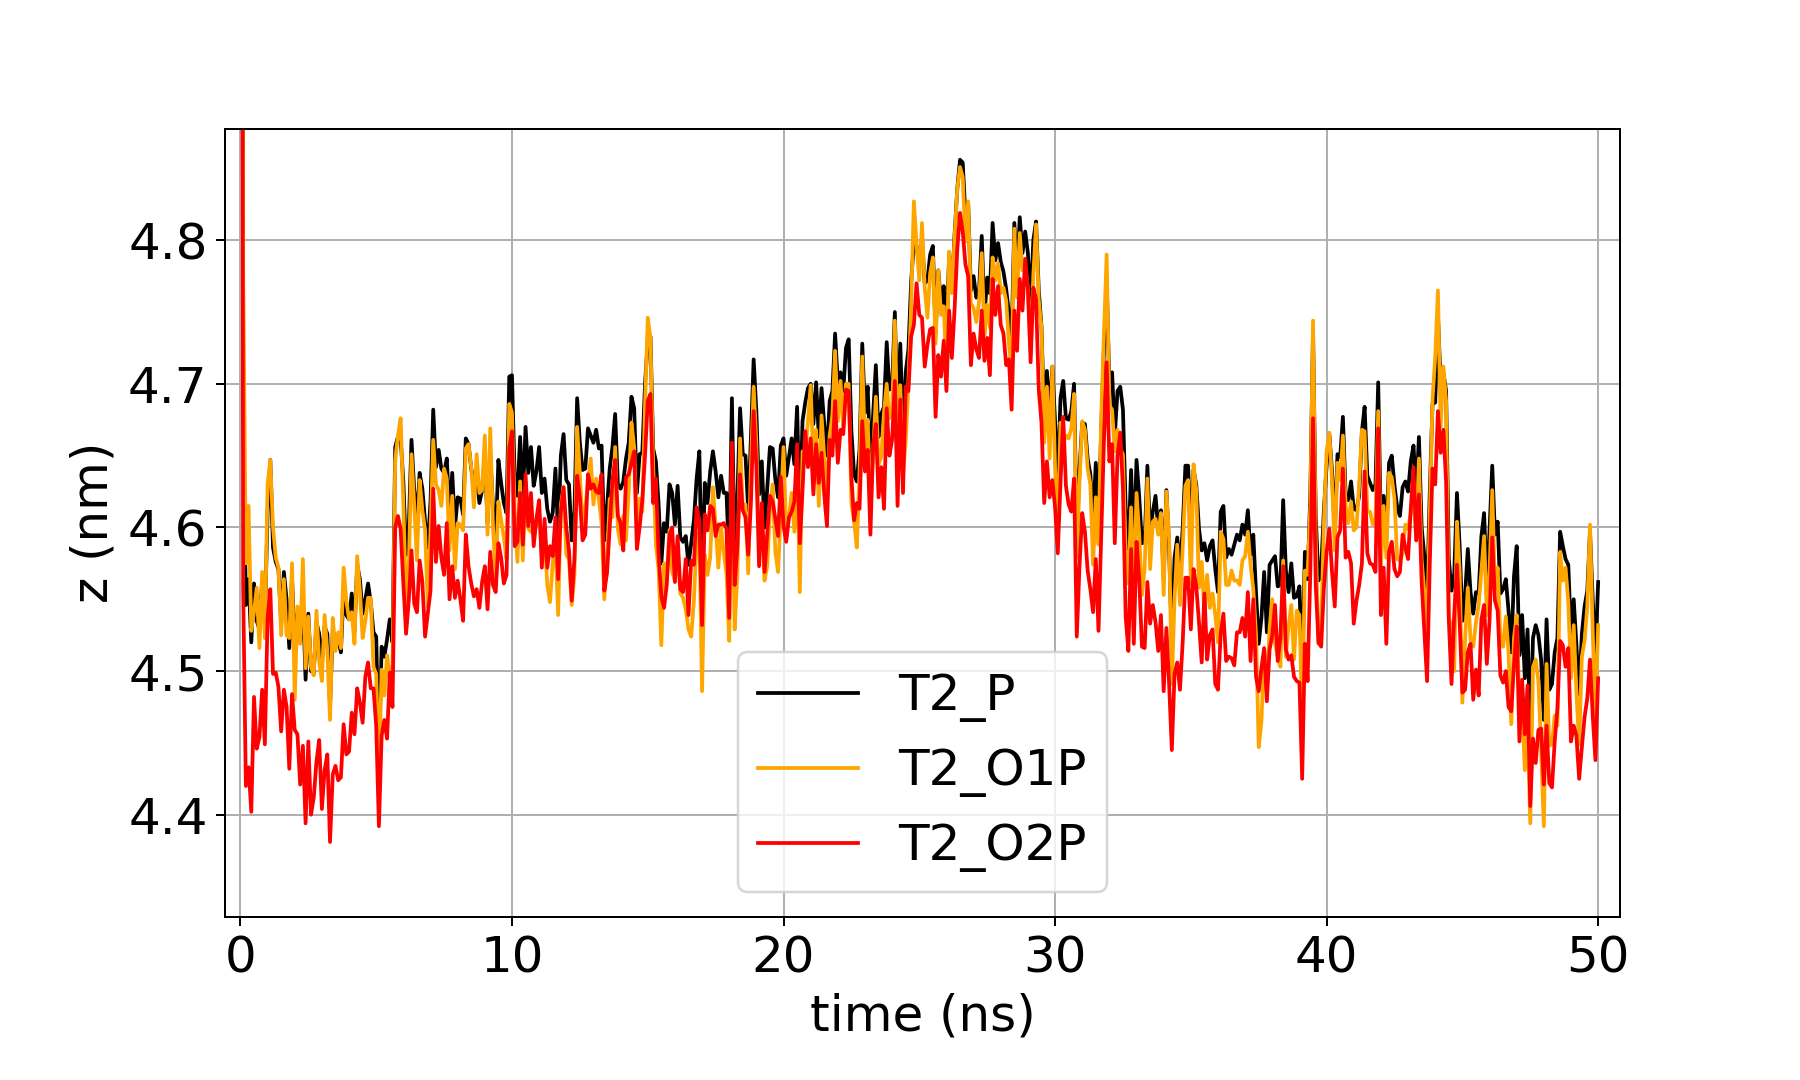

<IPython.core.display.Javascript object>


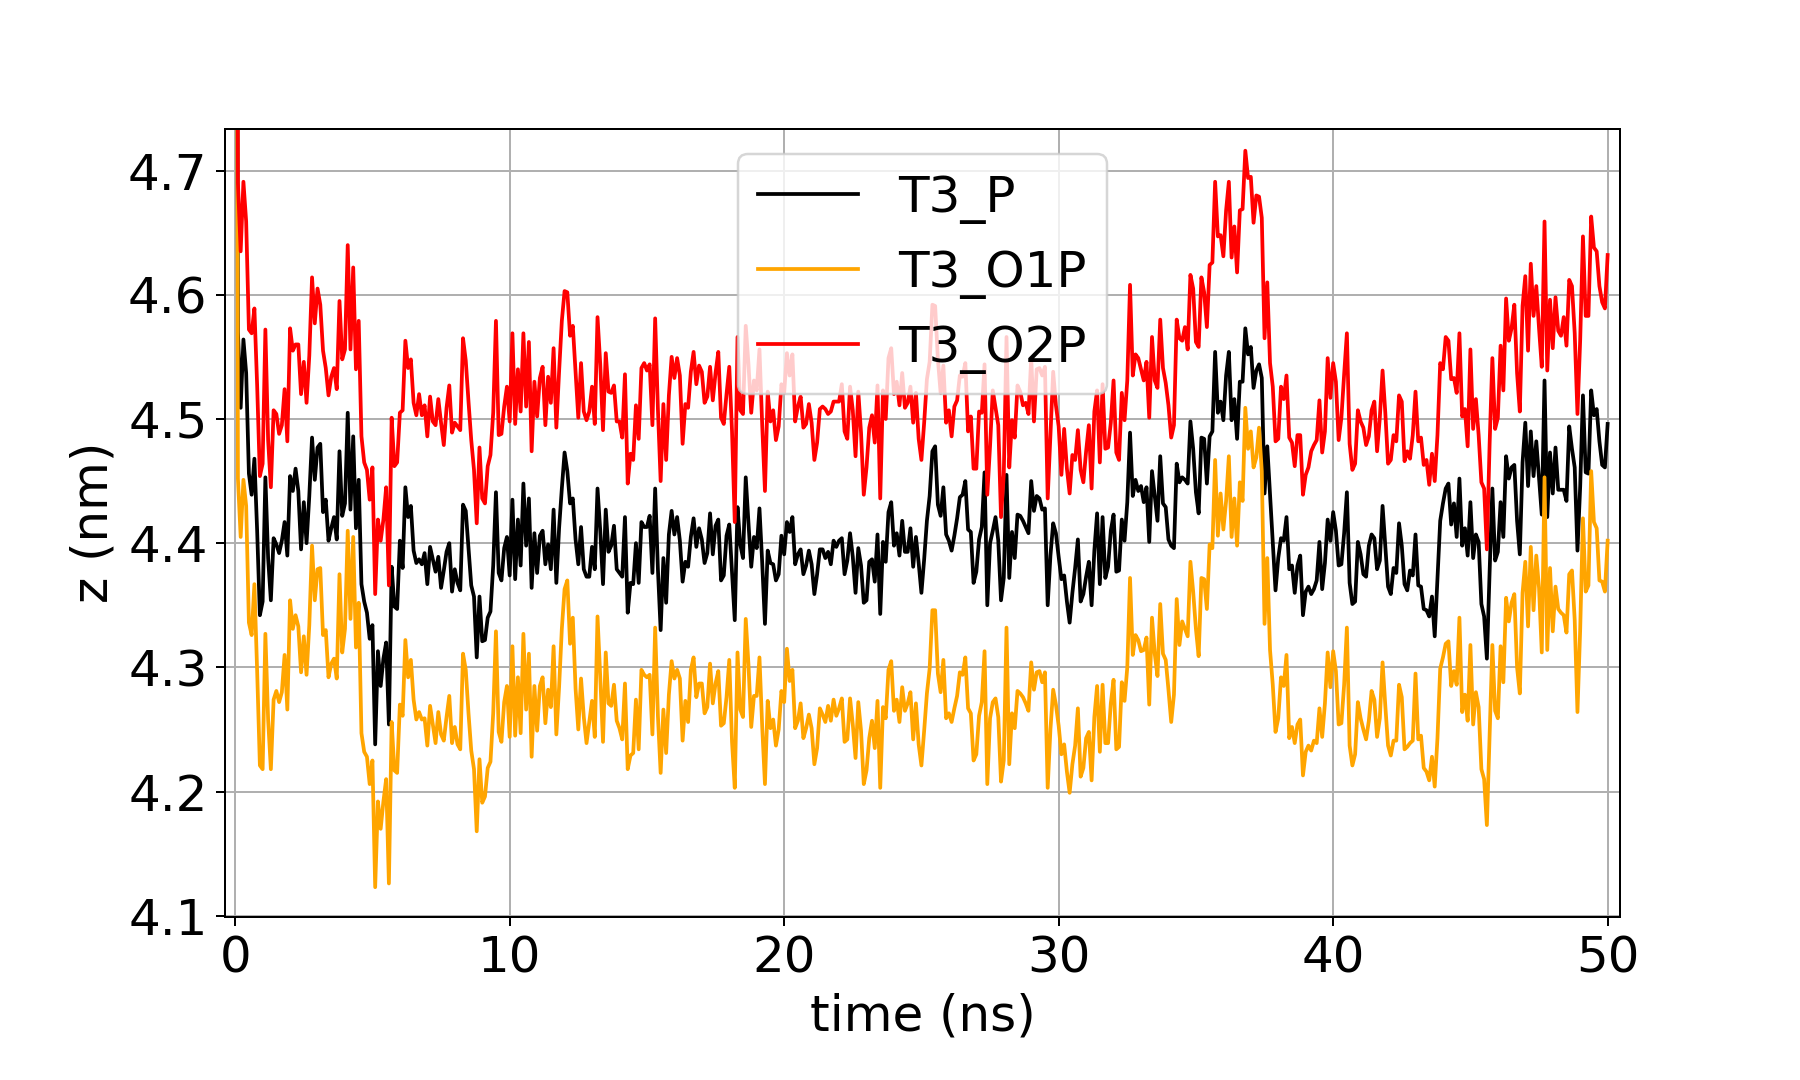

<IPython.core.display.Javascript object>


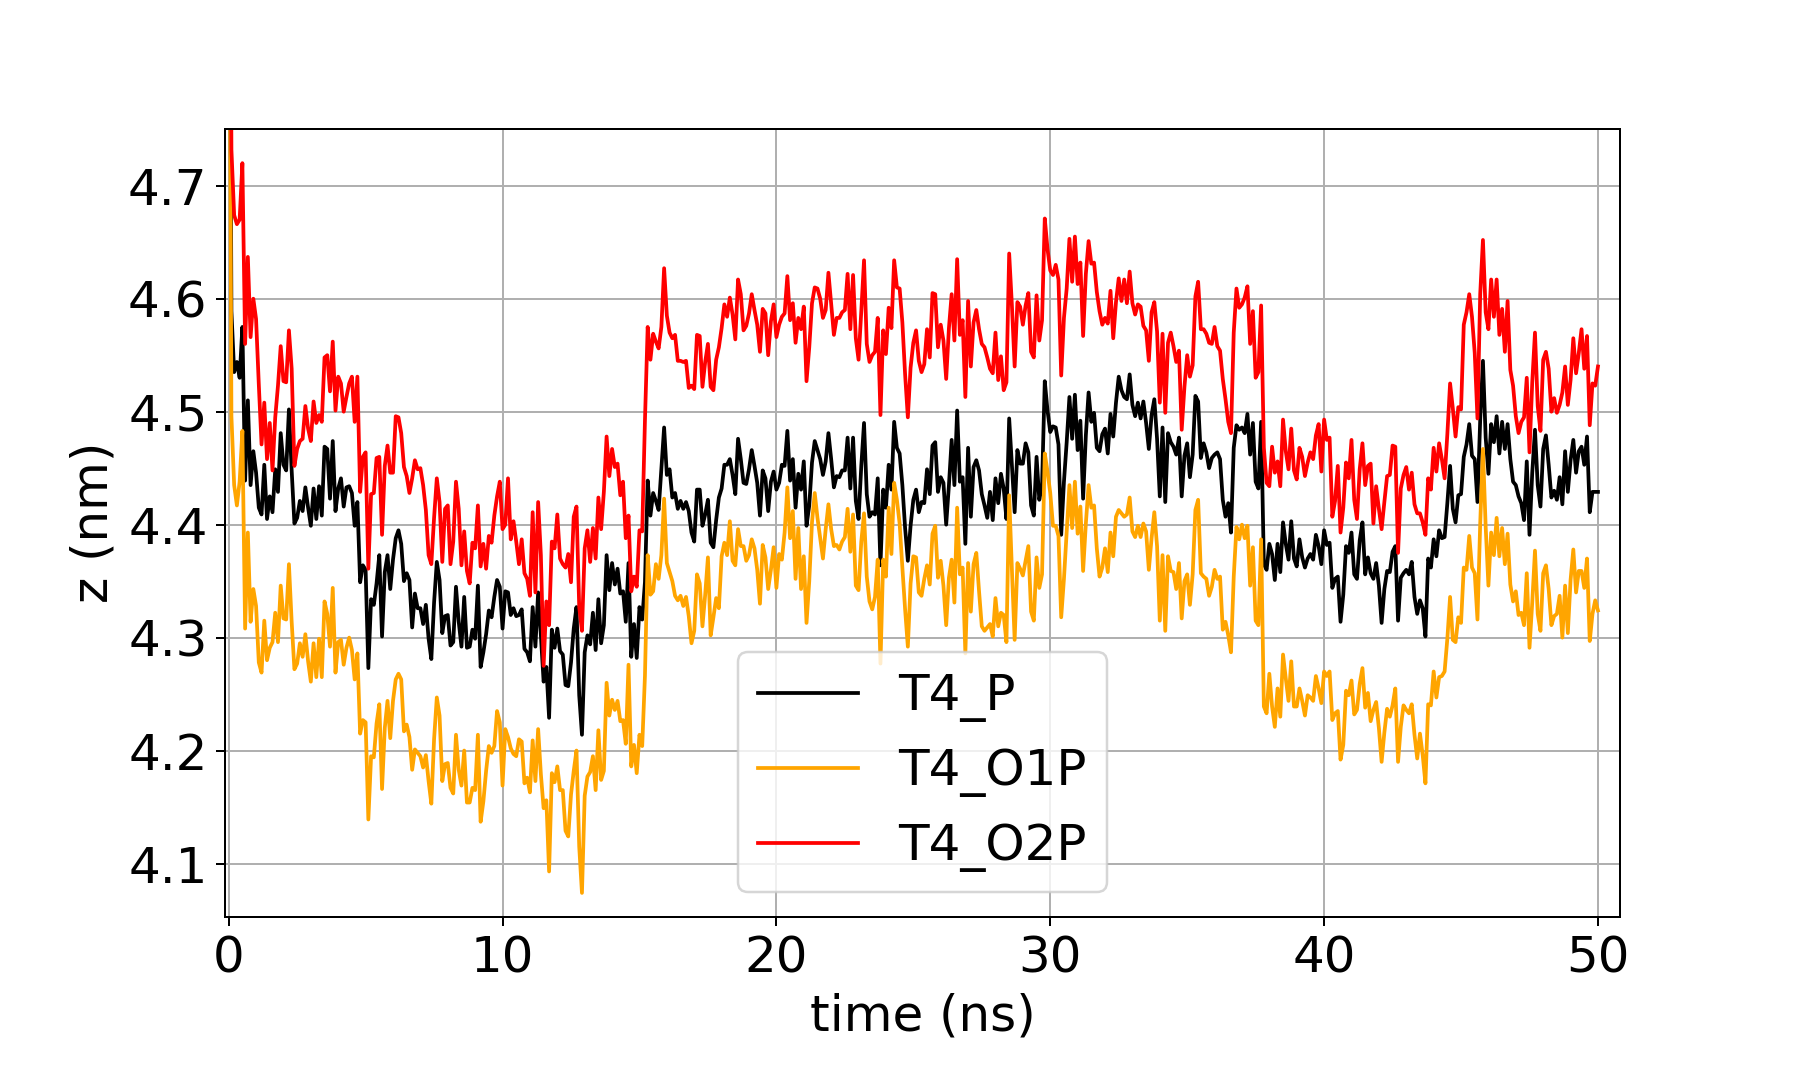

<IPython.core.display.Javascript object>


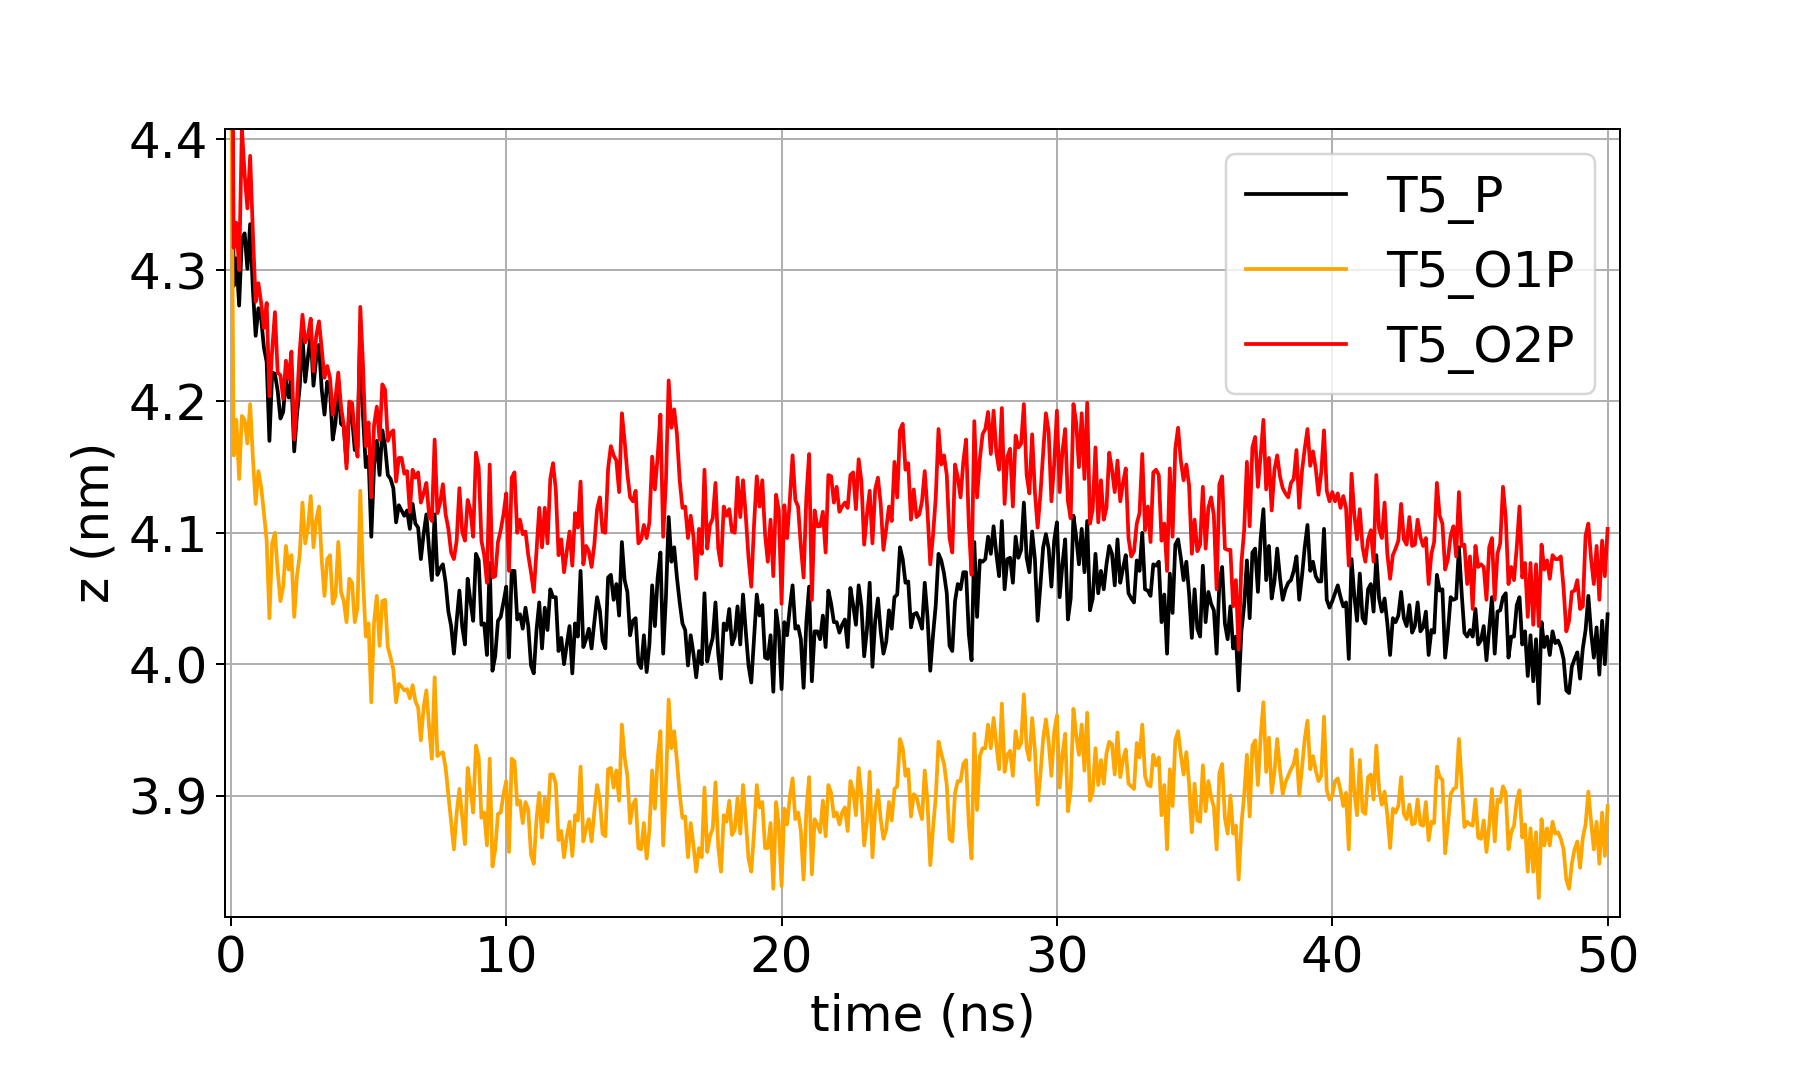

In [11]:
fontsize = 20
figsize = (10,6)
bottom = 0.15

# z-coordinate graphics for T2
plt.figure(figsize=figsize)
plt.plot(time,T2_P_position_z,'k',label='T2_P')
plt.plot(time,T2_O1P_position_z,'orange',label='T2_O1P')
plt.plot(time,T2_O2P_position_z,'red',label='T2_O2P')
plt.grid(True)
plt.xlabel('time (ns)',fontsize=fontsize)
plt.ylabel('z (nm)',fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.subplots_adjust(bottom=bottom) # Adds a little space at the bottom so xlabel isn't cropped

# z-coordinate graphics for T3
plt.figure(figsize=figsize)
plt.plot(time,T3_P_position_z,'k',label='T3_P')
plt.plot(time,T3_O1P_position_z,'orange',label='T3_O1P')
plt.plot(time,T3_O2P_position_z,'red',label='T3_O2P')
plt.grid(True)
plt.xlabel('time (ns)',fontsize=fontsize)
plt.ylabel('z (nm)',fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.subplots_adjust(bottom=bottom) # Adds a little space at the bottom so xlabel isn't cropped

# z-coordinate graphics for T4
plt.figure(figsize=figsize)
plt.plot(time,T4_P_position_z,'k',label='T4_P')
plt.plot(time,T4_O1P_position_z,'orange',label='T4_O1P')
plt.plot(time,T4_O2P_position_z,'red',label='T4_O2P')
plt.grid(True)
plt.xlabel('time (ns)',fontsize=fontsize)
plt.ylabel('z (nm)',fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.subplots_adjust(bottom=bottom) # Adds a little space at the bottom so xlabel isn't cropped

# z-coordinate graphics for T5
plt.figure(figsize=figsize)
plt.plot(time,T5_P_position_z,'k',label='T5_P')
plt.plot(time,T5_O1P_position_z,'orange',label='T5_O1P')
plt.plot(time,T5_O2P_position_z,'red',label='T5_O2P')
plt.grid(True)
plt.xlabel('time (ns)',fontsize=fontsize)
plt.ylabel('z (nm)',fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.subplots_adjust(bottom=bottom) # Adds a little space at the bottom so xlabel isn't cropped

In [12]:
# 2-d histogram of solvent water (all z values)

# Break out the oxygen atoms of the solvent
OWterm_frame = uframe.select_atoms('name OW')
print (np.shape(OWterm_frame.positions))

# Extract coordinates
OWx_frame = OWterm_frame.positions[:,0]/10; print(np.shape(OWx_frame)) # In nm
OWy_frame = OWterm_frame.positions[:,1]/10; print(np.shape(OWy_frame))
OWz_frame = OWterm_frame.positions[:,2]/10; print(np.shape(OWz_frame))

(2873, 3)
(2873,)
(2873,)
(2873,)


<IPython.core.display.Javascript object>


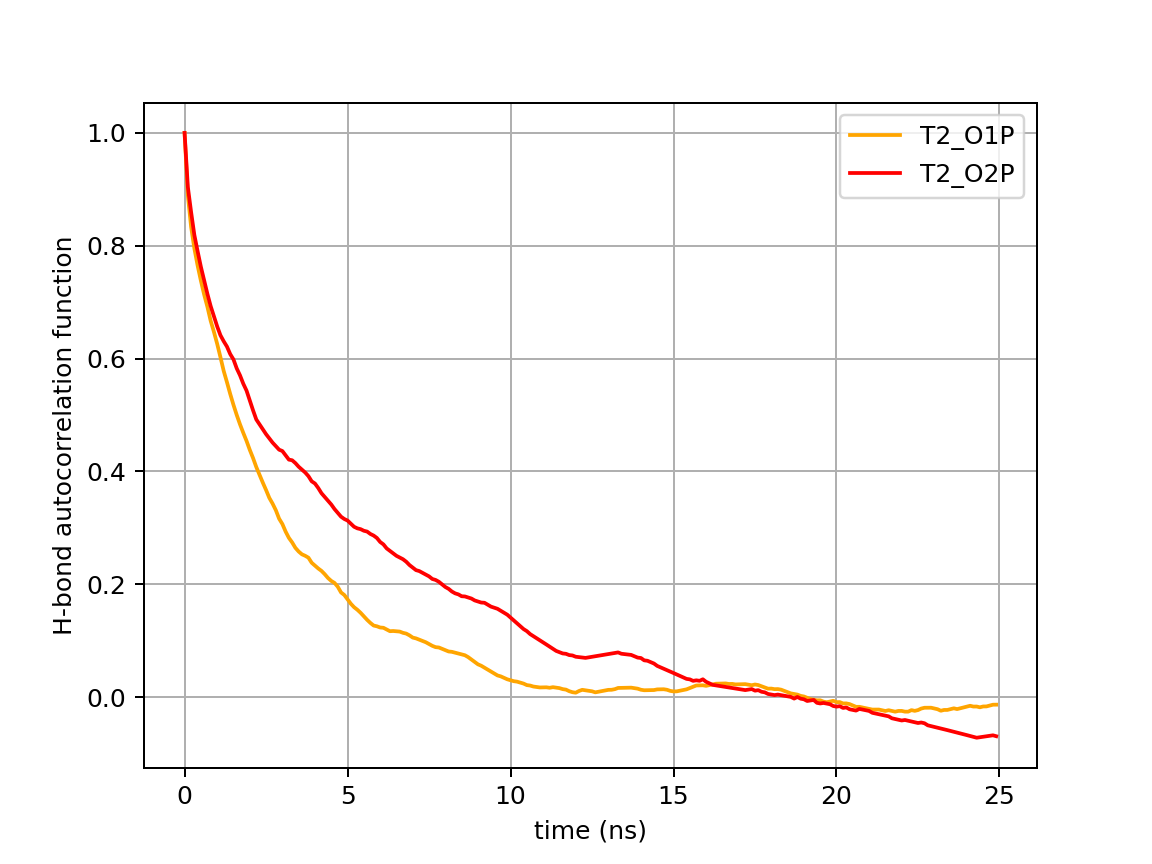

hbac_T2_O1P.xvg
(250, 5)
hbac_T2_O2P.xvg
(250, 5)


<IPython.core.display.Javascript object>


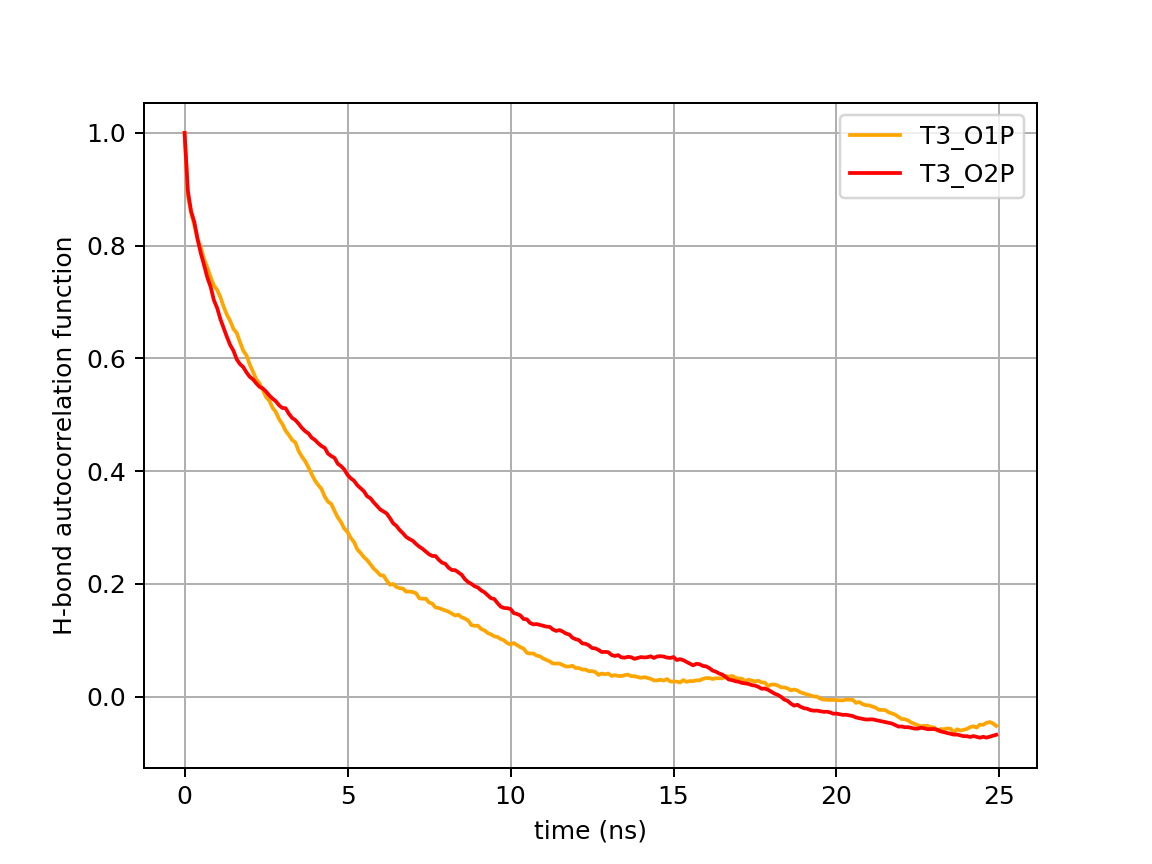

hbac_T3_O1P.xvg
(250, 5)
hbac_T3_O2P.xvg
(250, 5)


<IPython.core.display.Javascript object>


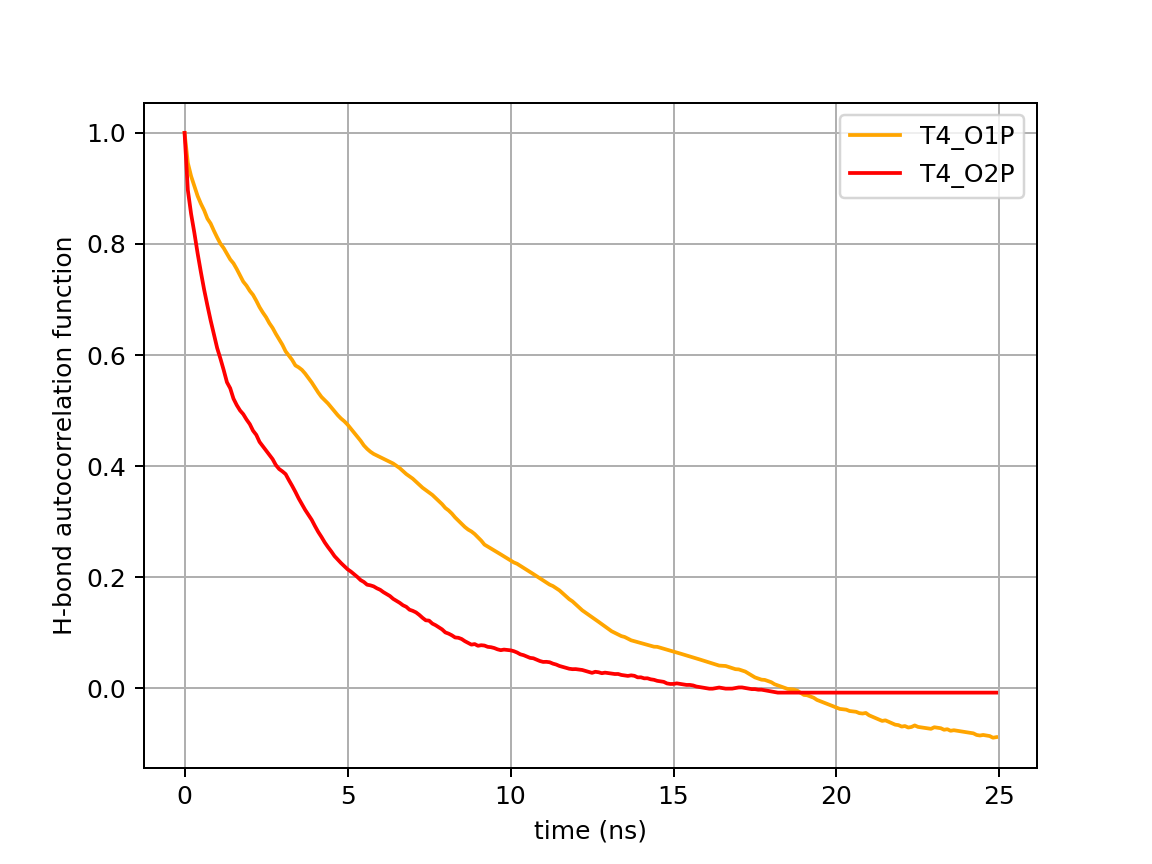

hbac_T4_O1P.xvg
(250, 5)
hbac_T4_O2P.xvg
(250, 5)


<IPython.core.display.Javascript object>


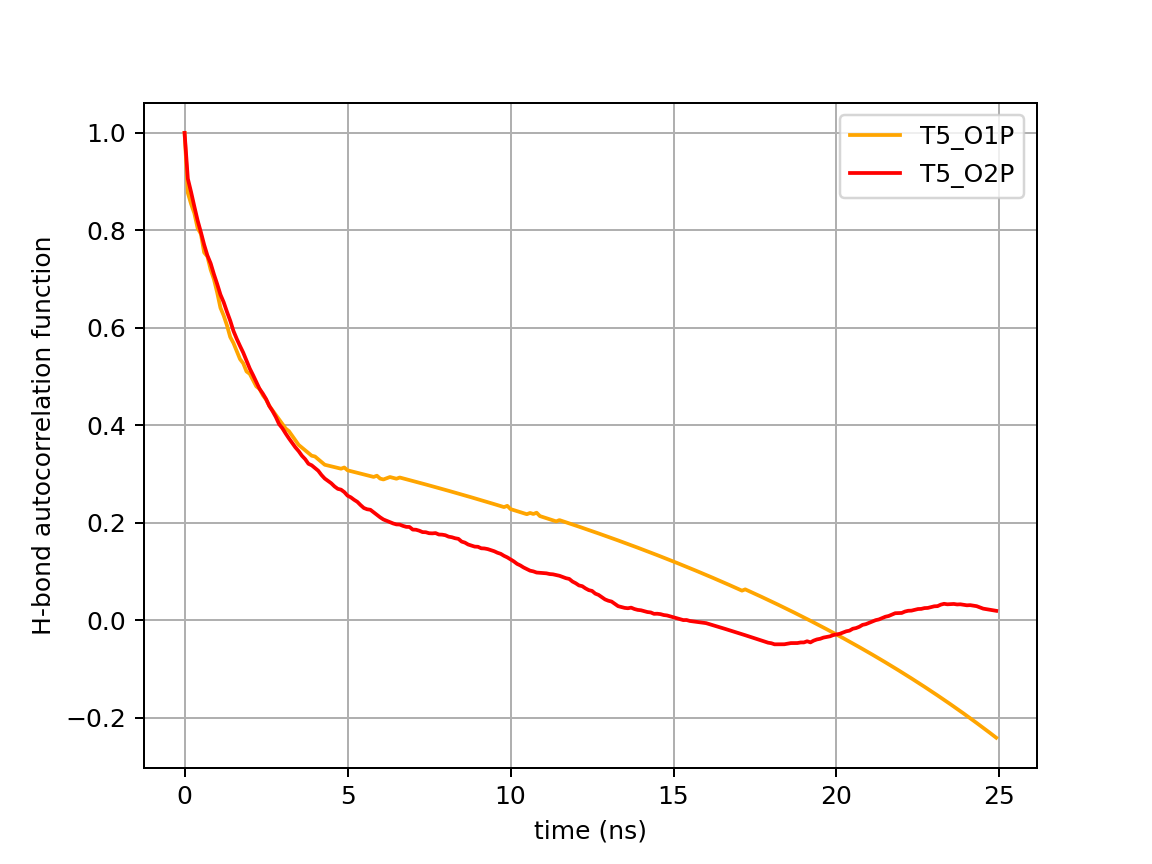

hbac_T5_O1P.xvg
(250, 5)
hbac_T5_O2P.xvg
(250, 5)


In [13]:
# for T2
plt.figure()
filename = 'hbac_T2_O1P.xvg'; print(filename)
hbac = mda.auxiliary.XVG.XVGReader(filename)
hbac_data = []
for auxstep in hbac:
    hbac_data.append(auxstep._data)
hbac_data = np.array(hbac_data)
print(np.shape(hbac_data))
plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='T2_O1P',color='orange')

filename = 'hbac_T2_O2P.xvg'; print(filename)
hbac = mda.auxiliary.XVG.XVGReader(filename)
hbac_data = []
for auxstep in hbac:
    hbac_data.append(auxstep._data)
hbac_data = np.array(hbac_data)
print(np.shape(hbac_data))
plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='T2_O2P',color='red')
plt.grid(True)
plt.xlabel('time (ns)')
plt.ylabel('H-bond autocorrelation function')
plt.legend()

# for T3
plt.figure()
filename = 'hbac_T3_O1P.xvg'; print(filename)
hbac = mda.auxiliary.XVG.XVGReader(filename)
hbac_data = []
for auxstep in hbac:
    hbac_data.append(auxstep._data)
hbac_data = np.array(hbac_data)
print(np.shape(hbac_data))
plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='T3_O1P',color='orange')

filename = 'hbac_T3_O2P.xvg'; print(filename)
hbac = mda.auxiliary.XVG.XVGReader(filename)
hbac_data = []
for auxstep in hbac:
    hbac_data.append(auxstep._data)
hbac_data = np.array(hbac_data)
print(np.shape(hbac_data))
plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='T3_O2P',color='red')
plt.grid(True)
plt.xlabel('time (ns)')
plt.ylabel('H-bond autocorrelation function')
plt.legend()

# for T4
plt.figure()
filename = 'hbac_T4_O1P.xvg'; print(filename)
hbac = mda.auxiliary.XVG.XVGReader(filename)
hbac_data = []
for auxstep in hbac:
    hbac_data.append(auxstep._data)
hbac_data = np.array(hbac_data)
print(np.shape(hbac_data))
plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='T4_O1P',color='orange')

filename = 'hbac_T4_O2P.xvg'; print(filename)
hbac = mda.auxiliary.XVG.XVGReader(filename)
hbac_data = []
for auxstep in hbac:
    hbac_data.append(auxstep._data)
hbac_data = np.array(hbac_data)
print(np.shape(hbac_data))
plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='T4_O2P',color='red')
plt.grid(True)
plt.xlabel('time (ns)')
plt.ylabel('H-bond autocorrelation function')
plt.legend()

# for T5
plt.figure()
filename = 'hbac_T5_O1P.xvg'; print(filename)
hbac = mda.auxiliary.XVG.XVGReader(filename)
hbac_data = []
for auxstep in hbac:
    hbac_data.append(auxstep._data)
hbac_data = np.array(hbac_data)
print(np.shape(hbac_data))
plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='T5_O1P',color='orange')

filename = 'hbac_T5_O2P.xvg'; print(filename)
hbac = mda.auxiliary.XVG.XVGReader(filename)
hbac_data = []
for auxstep in hbac:
    hbac_data.append(auxstep._data)
hbac_data = np.array(hbac_data)
print(np.shape(hbac_data))
plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='T5_O2P',color='red')
plt.grid(True)
plt.xlabel('time (ns)')
plt.ylabel('H-bond autocorrelation function')
plt.legend()

# for hbacitem in hbaclist:
#     filename = 'hbac_O2P.xvg'; print(filename)
#     hbac = mda.auxiliary.XVG.XVGReader(filename)
#     hbac_data = []
#     for auxstep in hbac:
#         hbac_data.append(auxstep._data)
#     hbac_data = np.array(hbac_data)
#     print(np.shape(hbac_data))
#     i+=1
# plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='O2P',color='yellow')

   
# plt.grid(True)
# plt.xlabel('time (ns)')
# plt.legend()

In [14]:
# # import MDAnalysis.analysis.msd as msd
# # # from MDAnalysis.tests.datafiles import RANDOM_WALK_TOPO, RANDOM_WALK
# # MSD = msd.EinsteinMSD(u, select='NA', msd_type='xy', fft=True)
# # # MSD.run()

# # filename = 'DNA_msd.xvg'; print(filename)
# # DNA_msd = mda.auxiliary.XVG.XVGReader(filename)
# # DNA_msd_data = []
# # for auxstep in DNA_msd:
# #     DNA_msd_data.append(auxstep._data)
# # DNA_msd_data = np.array(DNA_msd_data)

# filename = 'O2P_msd.xvg'; print(filename)
# O2P_msd = mda.auxiliary.XVG.XVGReader(filename)
# O2P_msd_data = []
# for auxstep in O2P_msd:
#     O2P_msd_data.append(auxstep._data)
# O2P_msd_data = np.array(O2P_msd_data)

# filename = 'O1P_msd.xvg'; print(filename)
# O1P_msd = mda.auxiliary.XVG.XVGReader(filename)
# O1P_msd_data = []
# for auxstep in O1P_msd:
#     O1P_msd_data.append(auxstep._data)
# O1P_msd_data = np.array(O1P_msd_data)

# filename = 'NA_msd.xvg'; print(filename)
# NA_msd = mda.auxiliary.XVG.XVGReader(filename)
# NA_msd_data = []
# for auxstep in NA_msd:
#     NA_msd_data.append(auxstep._data)
# NA_msd_data = np.array(NA_msd_data)

# plt.figure()
# plt.plot(O1P_msd_data[:,0]/1e3,O1P_msd_data[:,1],label='O1P',color='orange')
# plt.plot(O2P_msd_data[:,0]/1e3,O2P_msd_data[:,1],label='O2P',color='red')
# plt.grid(True)
# plt.legend()

# plt.figure()
# plt.plot(NA_msd_data[:,0]/1e3,NA_msd_data[:,1],label='NA',color='green')
# plt.grid(True)
# plt.legend()

In [15]:
# These slopes are taken from the graph, at two points -- not a fit
# The factor of 6 is 2𝑛 where 𝑛 is the dimension of particle motion
# (see https://mattermodeling.stackexchange.com/questions/9195/how-to-calculate-diffusion-coefficient-from-msd-graph-using-gromacs)
# So the agreement is great: we're getting numbers on the order of 2e-5 (units of cm^2/s x 1e-5) for O2P.

# For comparison, D for Na is on the order of 3e-3 (units of cm^2/s x 1e-5), which is 100x bigger.

# In the x-y direction (mostly y), displacement of O1P and O2P is on the order of 0.2 nm. 
# In the z-direction, the rms displacement looks like about 0.05 nm, and the net (over 400 ns) is about 0.02 nm
# So most of the msd seems to be in the x-y direction (again, mostly y).

slope = (.074-.026)/(250-50) # nm^2/ns
slope*=(1e2/1e9)**2/1e-9
slope*=1e5/6
print('D (O1P, from graph) = ', slope, 'cm^2/s x 1e-5')
slope_gromacs = 3.79e-5
print('D (O1P, reported by gromacs)', slope_gromacs)
print('ratio (graphical/gromacs)', slope/slope_gromacs)

slope = (.0439-.0195)/(250-50) # nm^2/ns
slope*=(1e2/1e9)**2/1e-9 # converts to cm^2/s
slope*=1e5/6 # Puts in units cm^2/s x 1e-5, as reported by gromacs
print('D (O2P), from graph = ', slope, 'cm^2/s x 1e-5')
slope_gromacs = 1.83e-5
print('D (O2P, reported by gromacs)', slope_gromacs)
print('ratio (graphical/gromacs)', slope/slope_gromacs)

D (O1P, from graph) =  3.9999999999999996e-05 cm^2/s x 1e-5
D (O1P, reported by gromacs) 3.79e-05
ratio (graphical/gromacs) 1.0554089709762533
D (O2P), from graph =  2.033333333333333e-05 cm^2/s x 1e-5
D (O2P, reported by gromacs) 1.83e-05
ratio (graphical/gromacs) 1.111111111111111


In [16]:
# # select atoms of interest into AtomGroups
# H = u.select_atoms('name H')
# N = u.select_atoms('name N4')
# O = u.select_atoms('name SOL')
# # create analysis object
# hb_ac = hbonds.HydrogenBondAutoCorrel(u,
#             acceptors=O, hydrogens=H, donors=N,
#             bond_type='continuous',
#             sample_time=2.0, nsamples=1000, nruns=20)
# # call run to gather results
# hb_ac.run()
# # attempt to fit results to exponential equation
# hb_ac.solve()
# # grab results from inside object
# tau = hb_ac.solution['tau']
# time = hb_ac.solution['time']
# results = hb_ac.solution['results']
# estimate = hb_ac.solution['estimate']
# # plot to check!
# plt.plot(time, results, 'ro')
# plt.plot(time, estimate)
# plt.show()

In [17]:
# # Getting the means of the last few hundred points
# backfromend = 150
# if backfromend > Ntimes:
#     backfromend = 0; 
#     print ('resetting to entire trajectory')
# else:
#     print ('using last', backfromend, 'times')
# O2P_position_x_mean = np.mean(O2P_position_x[-backfromend:])
# O2P_position_y_mean = np.mean(O2P_position_y[-backfromend:])
# O2P_position_z_mean = np.mean(O2P_position_z[-backfromend:])
# O1P_position_x_mean = np.mean(O1P_position_x[-backfromend:])
# O1P_position_y_mean = np.mean(O1P_position_y[-backfromend:])
# O1P_position_z_mean = np.mean(O1P_position_z[-backfromend:])
# # N4_position_x_mean = np.mean(N4_position_x[-backfromend:])
# # N4_position_y_mean = np.mean(N4_position_y[-backfromend:])
# # N4_position_z_mean = np.mean(N4_position_z[-backfromend:])